## Importing Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # To work with Categorical data
from imblearn.over_sampling import SMOTE # Used to handle Class Imbalance
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

## Data Loading & Understanding

In [56]:
# Read the CSV data to a pandas dataframe
df = pd.read_csv(r"C:\Users\91981\OneDrive\Desktop\Ml_revision_resources\Autism_Pred_Proj\train.csv")

#### Initial Inspection

In [57]:
df.shape

(800, 22)

In [58]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [59]:
# Display every columns of the dataframe
pd.set_option('display.max_columns',None)

In [60]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    str    
 13  ethnicity        800 non-null    str    
 14  jaundice         800 non-null    str    
 15  austim           800 non-null    str    
 16  contry_of_res    800 non-null    str    
 17  used_app_before  800 non-nu

In [62]:
 # Convert Age column datatype to integer
 df["age"] = df["age"].astype(int)

In [63]:
df["age"]

0      38
1      47
2       7
3      23
4      43
       ..
795    16
796    20
797     5
798    16
799    46
Name: age, Length: 800, dtype: int64

In [64]:
for col in df.columns:
    numerical_features = ["ID","age","result"]
    if col not in numerical_features:
        print(col, df[col].unique())
        print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender <StringArray>
['f', 'm']
Length: 2, dtype: str
--------------------------------------------------
ethnicity <StringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',          'Latino'

#### Preprocessing

##### 1. Drop ID and age_desc column
##### 2. In ethnicity column there are "?", "others" and "Others"
##### 3. In contry_of_res  column Spelling of Vietnam is written as "Viet Nam" & "Hong kong" to "China"
##### 4. In relation column we will only keep "Self" and replace everything else with "Others"

In [65]:
# Dropping ID and age_desc column
df = df.drop(columns = ["ID","age_desc"])

In [66]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [67]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

In [68]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',             'Viet Nam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',        'AmericanSamoa',              'Bahamas',
         'Saudi Arabia',              'Ireland',                'Aruba',
            'Sri Lanka',               'Russia',              'Bolivia',
           'Azerbaijan',              'Armenia',               'Serbia',
             'Ethiopia',               'Sweden',              'Iceland',
            'Hong Kong',               'Angola',                'China',
              'Germany',             

In [70]:
# Define the Mapping Dictionary for country name
mapping = {'Viet Nam':"Vietnam","AmericanSamoa":"United States","Hong kong":"China"}

# replace value in the country column
df["contry_of_res"] = df["contry_of_res"].replace(mapping)

In [71]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',              'Vietnam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',              'Bahamas',         'Saudi Arabia',
              'Ireland',                'Aruba',            'Sri Lanka',
               'Russia',              'Bolivia',           'Azerbaijan',
              'Armenia',               'Serbia',             'Ethiopia',
               'Sweden',              'Iceland',            'Hong Kong',
               'Angola',                'China',              'Germany',
                'Spain',             

In [72]:
# Target class Distribution
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

#### ** Insights:**
##### 1. Missing values ion ethinicity & relation
##### 2. age_desc column has only 1 unique value, so it is removed as it is not important for prediction.
##### 3. fixed country names
##### 4. Identified class imbalance in the target column.

### Exploratory Data Analysis (EDA)

In [73]:
df.shape

(800, 20)

In [74]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

In [75]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [77]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


### Univariate Analysis

#### Numerical Columns
##### - age
##### - result

In [80]:
# Set the desired Theme
sns.set_theme(style="whitegrid")

Mean:  27.96375
Median:  24.0


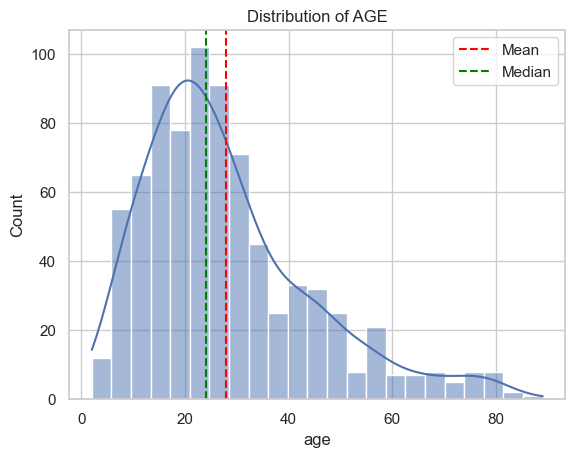

In [ ]:
# Histogram of "age"
sns.histplot(df['age'],kde = True)
plt.title("Distribution of AGE")

#Calculate Mean and Median
age_mean = df["age"].mean()
age_median = df["age"].median()
print("Mean: ",age_mean)
print("Median: ",age_median)

#Add Vertical lines for mean and median
plt.axvline(age_mean,color="red",linestyle="--",label="Mean")
plt.axvline(age_median,color="green",linestyle="--",label="Median")

plt.legend()
plt.show()

Mean:  8.537303106501248
Median:  9.605299308


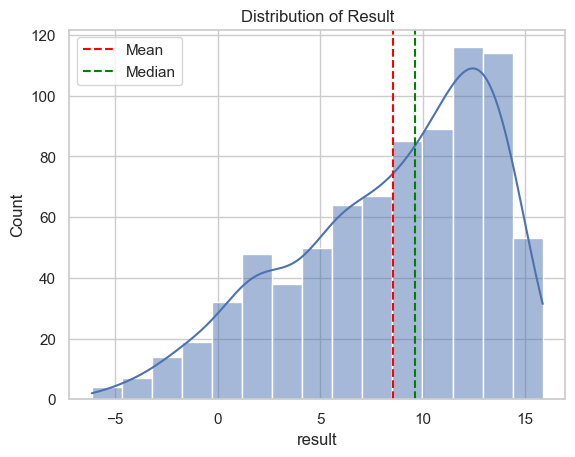

In [84]:
# Histogram of "result"
sns.histplot(df['result'],kde = True)
plt.title("Distribution of Result")

#Calculate Mean and Median
result_mean = df["result"].mean()
result_median = df["result"].median()
print("Mean: ",result_mean)
print("Median: ",result_median)

#Add Vertical lines for mean and median
plt.axvline(result_mean,color="red",linestyle="--",label="Mean")
plt.axvline(result_median,color="green",linestyle="--",label="Median")

plt.legend()
plt.show()

#### Box Plots for Identifying outliers in the NUmerical Columns

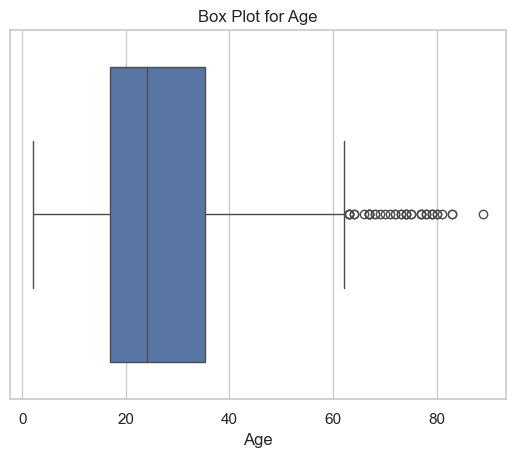

In [86]:
# Box Plot for AGE column
sns.boxplot(x = df['age'])
plt.title("Box Plot for Age")
plt.xlabel("Age")
plt.show()

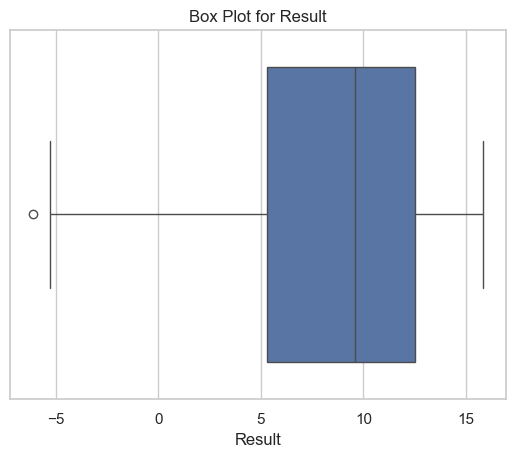

In [87]:
# Box Plot for RESULT column
sns.boxplot(x = df['result'])
plt.title("Box Plot for Result")
plt.xlabel("Result")
plt.show()

In [88]:
# Count the Outliers using IQR
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
IQR = q3-q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR
age_outliers = df[(df['age']< lower_bound) | (df["age"]>upper_bound)]

In [89]:
 # Total Number of Outlier values in AGE Column
 len(age_outliers)

39

In [91]:
# Count the Outliers using IQR
q1 = df['result'].quantile(0.25)
q3 = df['result'].quantile(0.75)
IQR = q3-q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR
result_outliers = df[(df['result']< lower_bound) | (df["result"]>upper_bound)]

In [92]:
len(result_outliers)

1

#### Univariate Analysis of Categorical Variables

In [94]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

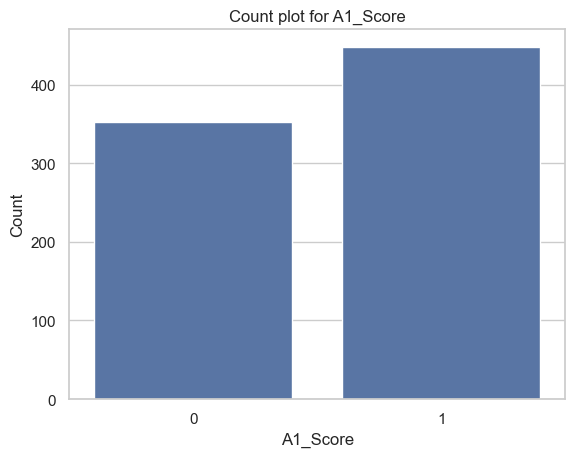

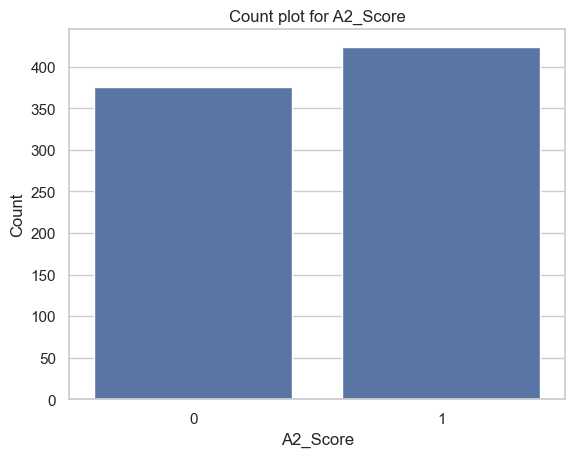

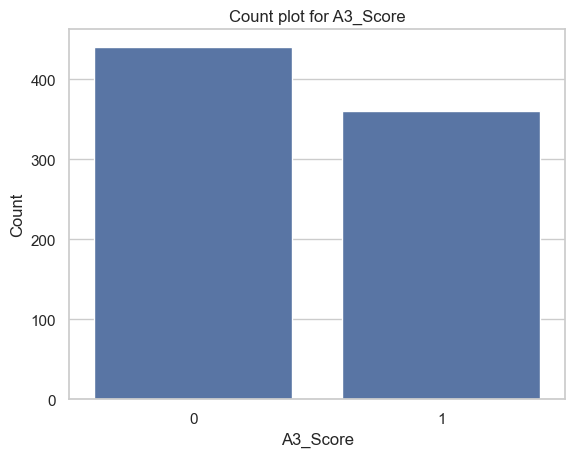

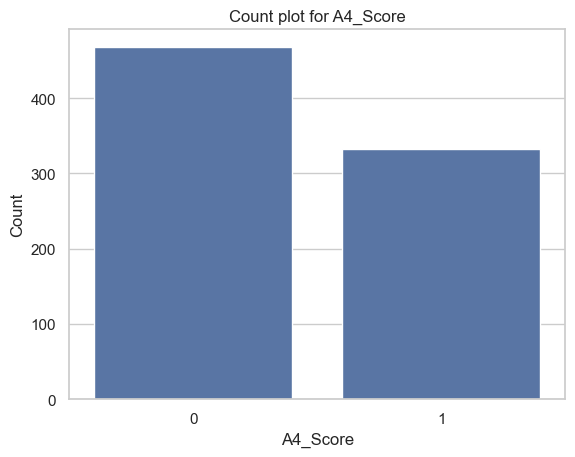

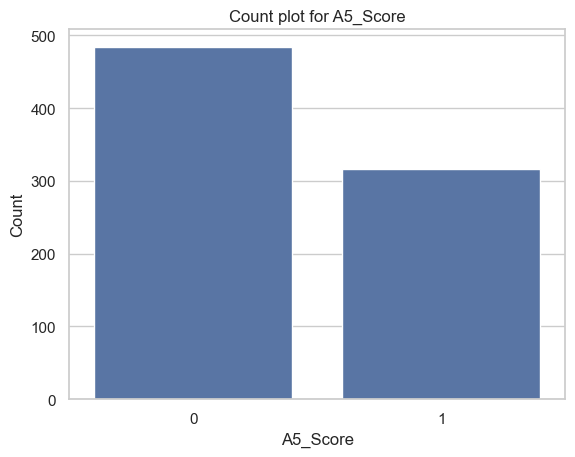

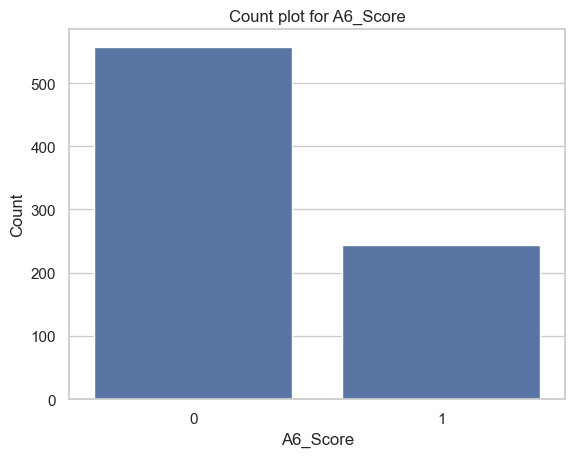

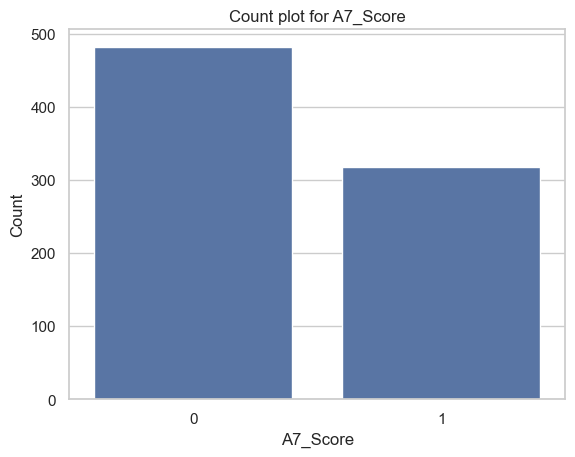

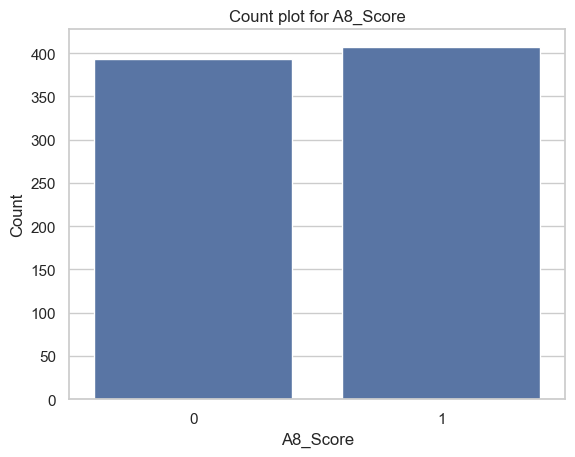

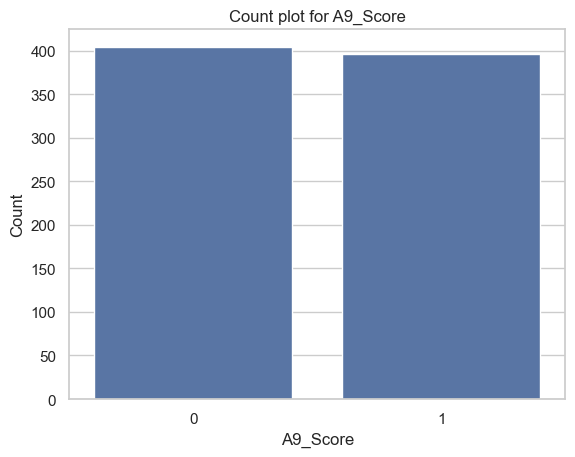

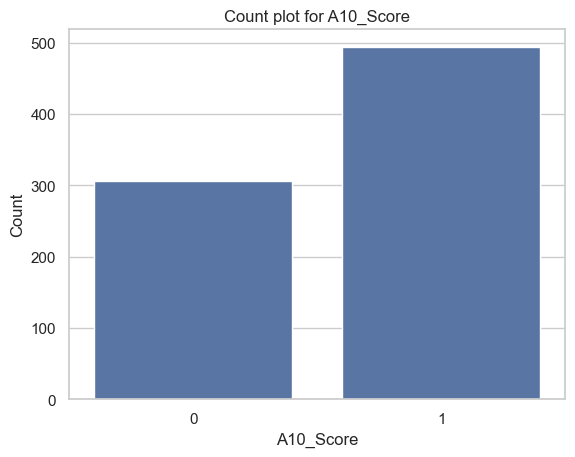

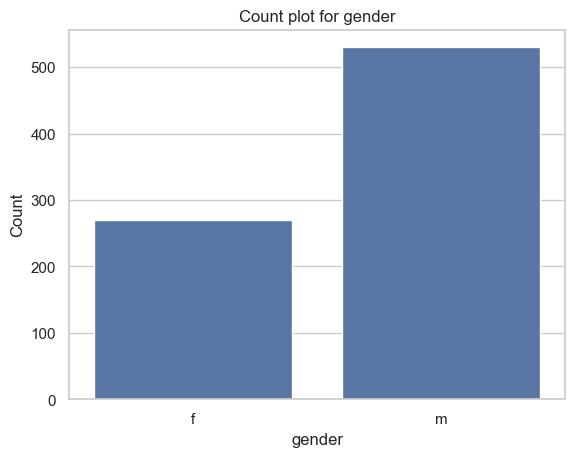

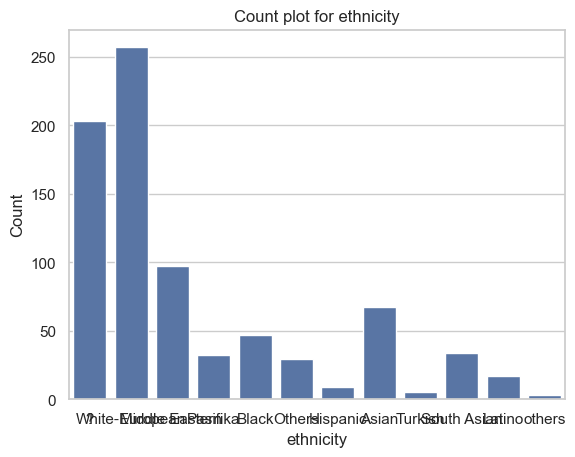

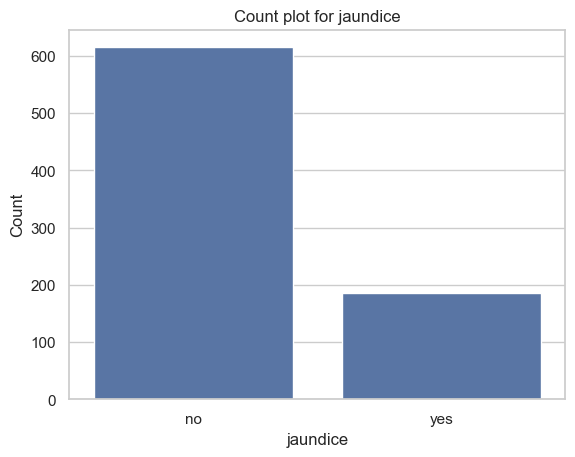

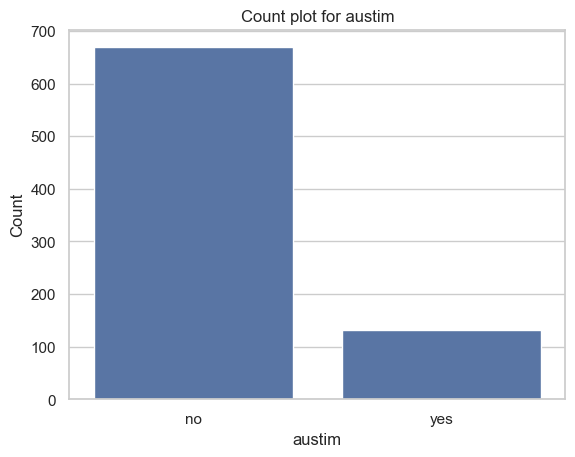

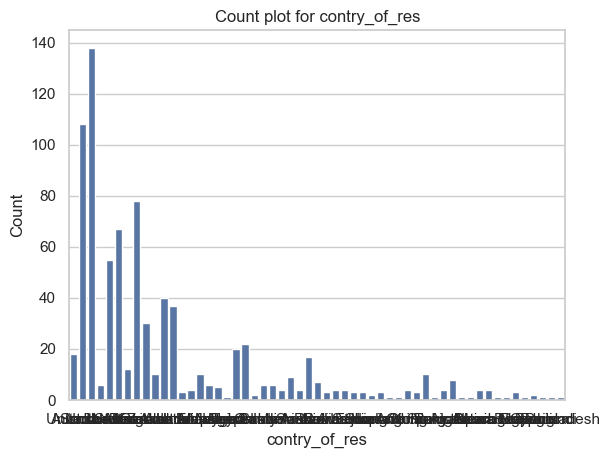

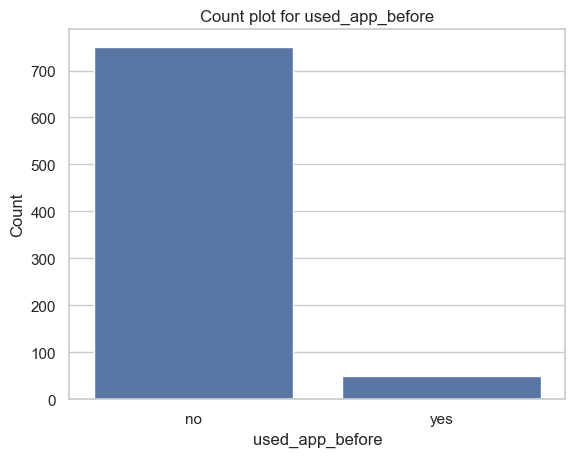

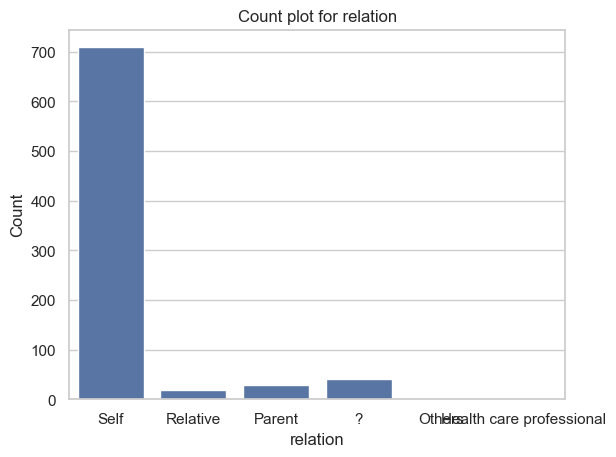

In [96]:
categorical_col = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score','gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before','relation']

for col in categorical_col:
    sns.countplot(x=df[col])
    plt.title(f"Count plot for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

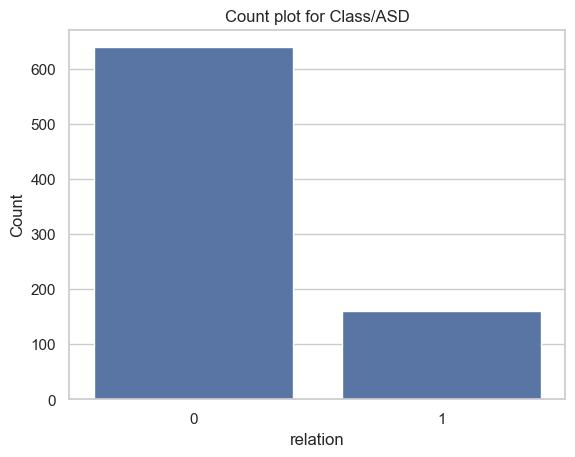

In [97]:
# Count plot for target column (Class/ASD)
sns.countplot(x=df['Class/ASD'])
plt.title(f"Count plot for Class/ASD")
plt.xlabel(col)
plt.ylabel("Count")
plt.show()

In [98]:
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

#### Handle missing value in Ethinicity and relation column

In [99]:
df['ethnicity'] = df['ethnicity'].replace({"?":"Others","others":"Others"})

In [102]:
df['ethnicity'].unique()

<StringArray>
[         'Others',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',        'Hispanic',           'Asian',         'Turkish',
     'South Asian',          'Latino']
Length: 10, dtype: str

In [108]:
df['relation']=df['relation'].replace({"?":"Others",
                                    "others":"Others",
                                    "Relative":"Others",
                                    "Parent":"Others",
                                    "Health care professional":"Others"})

In [109]:
df['relation'].unique()

<StringArray>
['Self', 'Others']
Length: 2, dtype: str

#### Label Encoding

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         800 non-null    int64  
 1   A2_Score         800 non-null    int64  
 2   A3_Score         800 non-null    int64  
 3   A4_Score         800 non-null    int64  
 4   A5_Score         800 non-null    int64  
 5   A6_Score         800 non-null    int64  
 6   A7_Score         800 non-null    int64  
 7   A8_Score         800 non-null    int64  
 8   A9_Score         800 non-null    int64  
 9   A10_Score        800 non-null    int64  
 10  age              800 non-null    int64  
 11  gender           800 non-null    str    
 12  ethnicity        800 non-null    str    
 13  jaundice         800 non-null    str    
 14  austim           800 non-null    str    
 15  contry_of_res    800 non-null    str    
 16  used_app_before  800 non-null    str    
 17  result           800 non-nu

In [112]:
# Identify columns with Object datatype
object_col = df.select_dtypes(include=["object"]).columns

C:\Users\91981\AppData\Local\Temp\ipykernel_17636\1570292753.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_col = df.select_dtypes(include=["object"]).columns


In [114]:
print(object_col)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='str')


In [115]:
# initialize Dictionary to store the encoders
encoders = {}

# Apply Label encoding and store the encoders
for col in object_col:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder # Saving the encoder for this column

#Save the encoders as a pickle file
with open("encoders.pkl","wb") as f:
    pickle.dump(encoders,f)

In [116]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

#### Bivariate Analysis

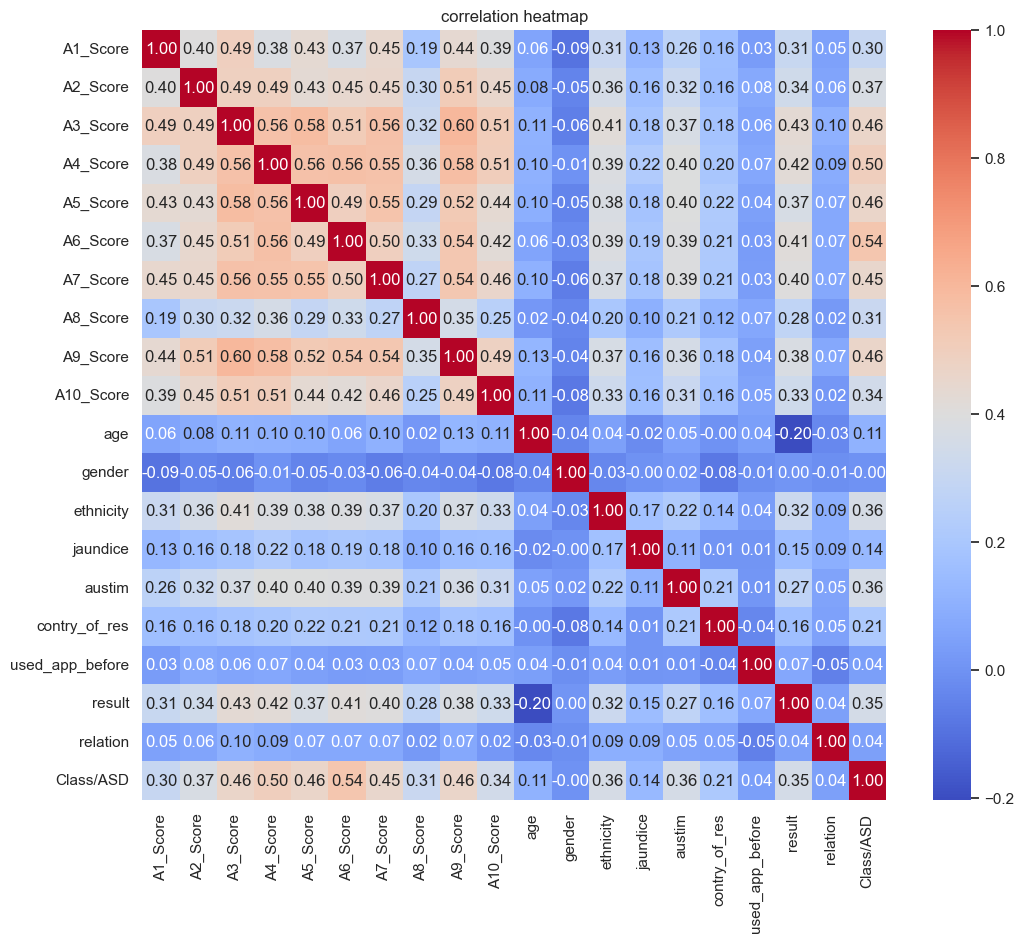

In [121]:
# correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation heatmap")
plt.show()

#### Insights from EDA: 
##### 1. There are few outliers in the numerical columns (age,results).
##### 2. There is a class imbalance in the target column.
##### 3. There is a class imbalance in categorical festures.
##### 4. We dont have any highly correlated column.
##### 5. Performed label encoding and saved the encoders.

### 4. Data Preprocessing

#### Handling Outliers

In [127]:
# Function to replace the outliers with median 
def replace_outliers_with_median(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    median = df[col].median()

    #replace outliers with median value
    df[col] = df[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

    return df

In [128]:
# Replace outliers in the "age" column
df = replace_outliers_with_median(df,"age")

# Replace outliers in the "result" column
df = replace_outliers_with_median(df,"result")

In [130]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,24,0,2.255185,1,0


### Train test split

In [131]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

In [135]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [136]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=42,test_size = 0.2)

In [137]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [138]:
y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

In [139]:
y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

#### SMOTE(Synthetic MMinority Oversampling technique)

In [140]:
smote = SMOTE(random_state = 42)

In [141]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [142]:
print(y_train_smote.shape)

(1030,)


In [144]:
print(y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


### 5. Model Training

In [147]:
# list of Classifiers
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Tree": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [150]:
# Dictionary to store the Cross validation result

cv_score = {
    
}

# perform 5-fold cross validation for each model
for model_name,model in models.items():
    print(f"Training {model_name} with default parameters...")
    scores = cross_val_score(model,x_train_smote,y_train_smote,cv=5,scoring="accuracy")
    cv_score[model_name] = scores
    print(f"{model_name} Cross_Validation Accuracy: {np.mean(scores):.2f}")
    print("-"*50)

Training Decision Tree with default parameters...
Decision Tree Cross_Validation Accuracy: 0.86
--------------------------------------------------
Training Random Tree with default parameters...
Random Tree Cross_Validation Accuracy: 0.92
--------------------------------------------------
Training XGBoost with default parameters...
XGBoost Cross_Validation Accuracy: 0.90
--------------------------------------------------


In [152]:
cv_score

{'Decision Tree': array([0.79126214, 0.89320388, 0.87864078, 0.85436893, 0.8592233 ]),
 'Random Tree': array([0.91262136, 0.93203883, 0.91747573, 0.91262136, 0.91747573]),
 'XGBoost': array([0.86407767, 0.91747573, 0.91262136, 0.89805825, 0.91747573])}

### 6. Model Selection and Hyperparameter Tuning

In [163]:
# Initializing mmodels

Decision_tree=DecisionTreeClassifier(random_state=42)
RandomForest_Tree=RandomForestClassifier(random_state=42)
XGBClassifier= XGBClassifier(random_state=42)


In [176]:
# Hyperparameter grids for RandomisedSearchCV

param_grid_dt = {
    "criterion":["gini","entropy"],
    "max_depth":[None,10,20,30,40,50,70],
    "min_samples_split":[2,5,7,10],
    "min_samples_leaf": [1,2,4]
}

param_grid_rf = {
    "n_estimators": [50,100,200,500],
    "max_depth": [None,10,20,30],
    "min_samples_split":[2,5,7,10],
    "min_samples_leaf": [1,2,4,5],
    "bootstrap":[True,False]
}

param_grid_xgb={
    "n_estimator":[50,100,200,500],
    "max_depth":[3,5,7,10],
    "learning_rate": [0.01,0.1,0.02,0.05,0.2,0.3],
    "subsample": [0.5,0.7,1.0],
    "colsample_bytree": [0.5,0.7,1.0]
}

In [177]:
# Hyperparameter tuning for 3 tree based models
# Perform RandomSearchCV fro each model
random_search_dt = RandomizedSearchCV(estimator = Decision_tree,param_distributions = param_grid_dt,n_iter=20,cv=5,scoring="accuracy",random_state =42)
random_search_rf = RandomizedSearchCV(estimator = RandomForest_Tree,param_distributions = param_grid_rf,n_iter=20,cv=5,scoring="accuracy",random_state =42)
random_search_xgb = RandomizedSearchCV(estimator = XGBClassifier,param_distributions = param_grid_xgb,n_iter=20,cv=5,scoring="accuracy",random_state =42)

In [179]:
# Fit the Models

random_search_dt.fit(x_train_smote,y_train_smote)
random_search_rf.fit(x_train_smote,y_train_smote)
random_search_xgb.fit(x_train_smote,y_train_smote)

c:\Users\91981\OneDrive\Desktop\Ml_revision_resources\Autism_Pred_Proj\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:42:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91981\OneDrive\Desktop\Ml_revision_resources\Autism_Pred_Proj\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:42:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91981\OneDrive\Desktop\Ml_revision_resources\Autism_Pred_Proj\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:42:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91981\OneDrive\Desktop\Ml_revision_resources\Autism_Pred_Proj\venv\Lib\site-packages\

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimator': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [180]:
# Get the Model with the best Score
best_model = None
best_score = 0

if random_search_dt.best_score_> best_score:
    best_model = random_search_dt.best_estimator_
    best_score = random_search_dt.best_score_

if random_search_rf.best_score_> best_score:
    best_model = random_search_rf.best_estimator_
    best_score = random_search_rf.best_score_

if random_search_xgb.best_score_> best_score:
    best_model = random_search_xgb.best_estimator_
    best_score = random_search_xgb.best_score_

In [182]:
print(f"Best Model: {best_model}")
print(f"best Cross-Validation Accuracy: {best_score: .2f}")

Best Model: RandomForestClassifier(max_depth=30, n_estimators=500, random_state=42)
best Cross-Validation Accuracy:  0.92


In [183]:
# Save the Best Model

with open("best_model.pkl","wb") as f:
    pickle.dump(best_model,f)

In [186]:
# Evaluate Test Data
y_test_pred = best_model.predict(x_test)
print("Accuracy:\n",accuracy_score(y_test,y_test_pred))
print("Confusion Matrix\n: ",confusion_matrix(y_test,y_test_pred))
print("Classification Report\n:",classification_report(y_test,y_test_pred))

Accuracy:
 0.8375
Confusion Matrix
:  [[107  17]
 [  9  27]]
Classification Report
:               precision    recall  f1-score   support

           0       0.92      0.86      0.89       124
           1       0.61      0.75      0.68        36

    accuracy                           0.84       160
   macro avg       0.77      0.81      0.78       160
weighted avg       0.85      0.84      0.84       160

